In [ ]:
import gsd.hoomd
from scipy.spatial import ConvexHull
import numpy as np 
import freud

import numpy as np
import matplotlib.pyplot as plt
import alphashape
import math
from shapely.geometry import Polygon
import networkx as nx

import signac
project=signac.get_project()
import pandas as pd

parameters = {"font.family": "Arial",
                  'font.size': 12,
                  'figure.dpi': 300,
                  'savefig.dpi':300,
                  'axes.labelsize': 14,
                  'figure.figsize': (6,4),
                  'figure.titlesize': 14,
                  'lines.linewidth': 2,
                  'xtick.major.size':5,
                  'ytick.major.size':5
                 }
plt.rcParams.update(parameters)

In [ ]:
def harmonic_U(k, sigma, r):
    V = k/2 * pow((1. - r/sigma), 2)
    return V
        
def harmonic_F(k, sigma, r):
    F = k/sigma * (1. - r/sigma)
    return F

In [ ]:
def alpha_shape_IQ(frame, N_part, N_mesh, box, alpha = None):
    total = 0
    IQs = []
    areas = []
    perimeters = []
    for i in range(N_part): 
        start = i * N_mesh
        end = (i + 1) * N_mesh
        mesh_positions = frame.particles.position[start:end]
        pts=box.unwrap(mesh_positions,imgs = frame.particles.image[start:end])
        pts = pts[:, 0:2] 
        if alpha is None: 
            shape = alphashape.alphashape(pts)
        else: 
            shape = alphashape.alphashape(pts, alpha) 
        area = shape.area
        perimeter = shape.length
        IQ = 4 * np.pi * area / perimeter**2
        IQs.append(IQ)
        areas.append(area)
        perimeters.append(perimeter)
        # plot out each alpha shape 
        # plt.figure(figsize=(4,4))
        # plt.scatter(pts[:,0], 
        #             pts[:,1], 
        #             s=10)
        # x,y = shape.exterior.xy
        # plt.plot(x,y,linewidth=2)
        # plt.axis("equal")
        # plt.xlabel("x")
        # plt.ylabel("y")
        # plt.title(f"mesh {i}")
        # plt.show
    IQs = np.array(IQs)
    areas = np.array(areas)
    perimeters = np.array(perimeters)
    return {
        "IQs": IQs, 
        "areas": areas, 
        "perimeters": perimeters, 
        "avg_IQ": float(IQs.mean()), 
        "total_area": float(areas.sum()), 
        "avg_area": float(areas.mean())
    }

def packing_eff(frame, N_part, N_mesh, alpha = None): 
    stats = alpha_shape_IQ(frame, N_part, N_mesh, box, alpha)
    Lx = frame.configuration.box[0]
    Ly = frame.configuration.box[1]
    box_area = Lx * Ly
    efficiency = float(stats["total_area"] / box_area)
    return {"efficiency": efficiency}


def contact_network(frame, N_part, N_mesh, distance): 
    G = nx.Graph()
    G.add_nodes_from(range(N_part))
    for i in range(N_part):
        start = i * N_mesh
        end = (i + 1) * N_mesh
        mesh_i = frame.particles.position[start:end]
        # mesh_i = box.unwrap(mesh_i,imgs = frame.particles.image[start:end])
        for j in range(i + 1, N_part):
            start = j * N_mesh
            end = (j + 1) * N_mesh
            mesh_j = frame.particles.position[start:end]
            # mesh_j = box.unwrap(mesh_j,imgs = frame.particles.image[start:end])  
            d = np.linalg.norm(
                mesh_i[:,None,:] - mesh_j[None,:,:],
                axis=2
            )
            if np.min(d) < distance:
                G.add_edge(i,j)
    return G


def mesh_force(forces, N_part, N_mesh): 
    net_force = []
    magnitudes = []
    for i in range(N_part): 
        start = i * N_mesh
        end = (i + 1) * N_mesh
        mesh_forces = forces[start:end]
        total_force = np.sum(mesh_forces[:, 0:2], axis=0)
        magnitude = np.linalg.norm(total_force)
        net_force.append(total_force)
        magnitudes.append(magnitude)
    net_force = np.array(net_force)
    magnitudes = np.array(magnitudes)
    return {
        "net_force": net_force, 
        "magnitudes": magnitudes, 
        "avg_net_force": float(magnitudes.mean()), 
        "min_net_force": float(magnitudes.min()), 
        "max_net_force": float(magnitudes.max()), 
        "std_net_force": float(magnitudes.std())
    }

    
def forces_between_mesh(frame, N_part, N_mesh, sigma, k_harm, box): 
    """
    returns the number of particles in contact for each pair of touching meshes, the total force between them, and the mean force per particle
    """
    positions = frame.particles.position
    meshes = [positions[i*N_mesh:(i+1)*N_mesh] for i in range(N_part)]

    pair_force = {}
    pair_contacts = {}

    for i in range(N_part):
        for j in range(i + 1, N_part):
            pair_force[(i, j)] = 0.0
            pair_contacts[(i, j)] = 0

    for i in range(N_part):
        pts_i = meshes[i]

        for j in range(i + 1, N_part):
            pts_j = meshes[j]

            diff = pts_i[:, None, :] - pts_j[None, :, :]
            diff = box.wrap(diff.reshape(-1, 3)).reshape(diff.shape)

            d = np.linalg.norm(diff, axis=-1)

            mask = d < sigma

            if not np.any(mask):
                continue

            pair_contacts[(i, j)] = int(np.sum(mask))

            F_mag = harmonic_F(k_harm, sigma, d[mask])

            pair_force[(i, j)] = float(np.sum(F_mag))

    touching_pairs = [pair for pair in pair_contacts if pair_contacts[pair] > 0]

    if len(touching_pairs) == 0:
        return {
            "avg_particle_num": 0.0,
            "avg_pair_force": 0.0,
            "avg_particle_force": 0.0,
            "contact_fraction": 0.0,
            "pair_force": pair_force,
            "pair_contacts": pair_contacts,
        }

    avg_particle_num = float(np.mean([pair_contacts[p] for p in touching_pairs]))
    avg_pair_force = float(np.mean([pair_force[p] for p in touching_pairs]))
    avg_particle_force = float(np.mean([pair_force[p] / pair_contacts[p] for p in touching_pairs]))
    contact_fraction = float(np.mean([pair_contacts[p] / N_mesh for p in touching_pairs]))

    return {
        "avg_particle_num": avg_particle_num,
        "avg_pair_force": avg_pair_force,
        "avg_particle_force": avg_particle_force,
        "contact_fraction": contact_fraction,
        "pair_force": pair_force,
        "pair_contacts": pair_contacts,
    }

    
def contact_degrees(frame, N_part, N_mesh, distance, box): 
    G = contact_network(frame, N_part, N_mesh, distance)
    degrees = np.array([G.degree(i) for i in range(N_part)])
    return {
        "degrees": degrees, 
        "avg_degree": float(degrees.mean()), 
        "num_edges": float(G.number_of_edges()), 
        "min_degree": float(degrees.min()), 
        "max_degree": float(degrees.max())
    }


In [ ]:
def analyze_frame(frame, N_part, N_mesh, sigma, box, k_harm, alpha = None): 
    box = freud.box.Box.from_box(frame.configuration.box)
    iq = alpha_shape_IQ(frame, N_part, N_mesh, box, alpha)
    packing = packing_eff(frame, N_part, N_mesh, alpha)
    degree = contact_degrees(frame, N_part, N_mesh, sigma, box)
    meshforce = mesh_force(frame.log["particles/md/pair/Table/forces"], N_part, N_mesh) 
    pairforce = forces_between_mesh(frame, N_part, N_mesh, sigma, k_harm, box)
    results = {}
    results.update({"avg_IQ": iq["avg_IQ"], "total_area": iq["total_area"], "avg_area": iq["avg_area"]})
    results.update(packing)
    results.update({"degrees": degree["degrees"], "avg_degree": degree["avg_degree"], "num_edges": degree["num_edges"]})
    results.update({"avg_particle_num": pairforce["avg_particle_num"], "avg_pair_force": pairforce["avg_pair_force"], "avg_particle_force": pairforce["avg_particle_force"]})
    results.update({"avg_net_force": meshforce["avg_net_force"], "min_net_force": meshforce["min_net_force"], "max_net_force": meshforce["max_net_force"], "std_net_force": meshforce["std_net_force"]})
    for key, value in results.items(): 
        if isinstance(value, float): 
            results[key] = round(value, 3)
        elif isinstance(value, np.ndarray): 
            results[key] = np.round(value, 3) 
        elif isinstance(value, dict): 
            results[key] = {k: round(v,3) if isinstance(v, float) else v for k, v in value.items()}
    return results

In [ ]:
def frame_density(frame, N_part, R, sigma): 
    area = np.pi * (R + sigma / 2) ** 2
    Lx, Ly = frame.configuration.box[0], frame.configuration.box[1]
    return N_part * area / (Lx * Ly) 

def iq_vs_density(job, N_part, N_mesh, R, sigma, alpha = 0.7, step = 100): 
    traj = gsd.hoomd.open(job.fn("trajectory.gsd"))
    records = []
    for frame in traj[::step]: 
        box = freud.box.Box.from_box(frame.configuration.box)
        phi = frame_density(frame, N_part, R, sigma)
        try: 
            stats = alpha_shape_IQ(frame, N_part, N_mesh, box, alpha)
        except Exception: 
            continue 

        records.append({"timestep": frame.configuration.step, "phi": phi, "avg_IQ": stats["avg_IQ"]})
    return pd.DataFrame(records) 

def plot_iq_vs_density(project, N_part, R, sigma, n_bins=10):
    all_data = []
    for job in project.find_jobs({"N_part": N_part, "N_mesh": 256, "k_volume_scale": 100000, "k_harm": 100, "sigma": sigma}):
        if job.sp.k_area_scale != 50: 
            df = iq_vs_density(job, N_part, job.sp.N_mesh, R, sigma, alpha = 0.7, step = 100)
            df["k_area_scale"] = job.sp.k_area_scale
            df["trial_number"] = job.doc.get("reference_trial_number")
            all_data.append(df)

    all_data = pd.concat(all_data, ignore_index=True)
    all_data["phi_bin"] = pd.cut(all_data["phi"], bins=n_bins)

    for k in sorted(all_data["k_area_scale"].unique()):
        subset = all_data[all_data["k_area_scale"] == k]
        grouped = subset.groupby("phi_bin", observed=True)["avg_IQ"]
        centers = [b.mid for b in grouped.mean().index]
        mean, std = grouped.mean().values, grouped.std().values
        plt.plot(centers, mean, marker=".", label=rf"k$_{{\mathrm{{area}}}}$ scale = {k}")
        # plt.fill_between(centers, mean - std, mean + std, alpha=0.15)

    plt.xlabel("Density, φ")
    plt.ylabel("Mean IQ")
    plt.title(rf"Average IQ vs. Density ($N_{{\mathrm{{part}}}} = {N_part}$)")
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f"{N_part} IQ vs density.png", bbox_inches='tight')
    plt.show()

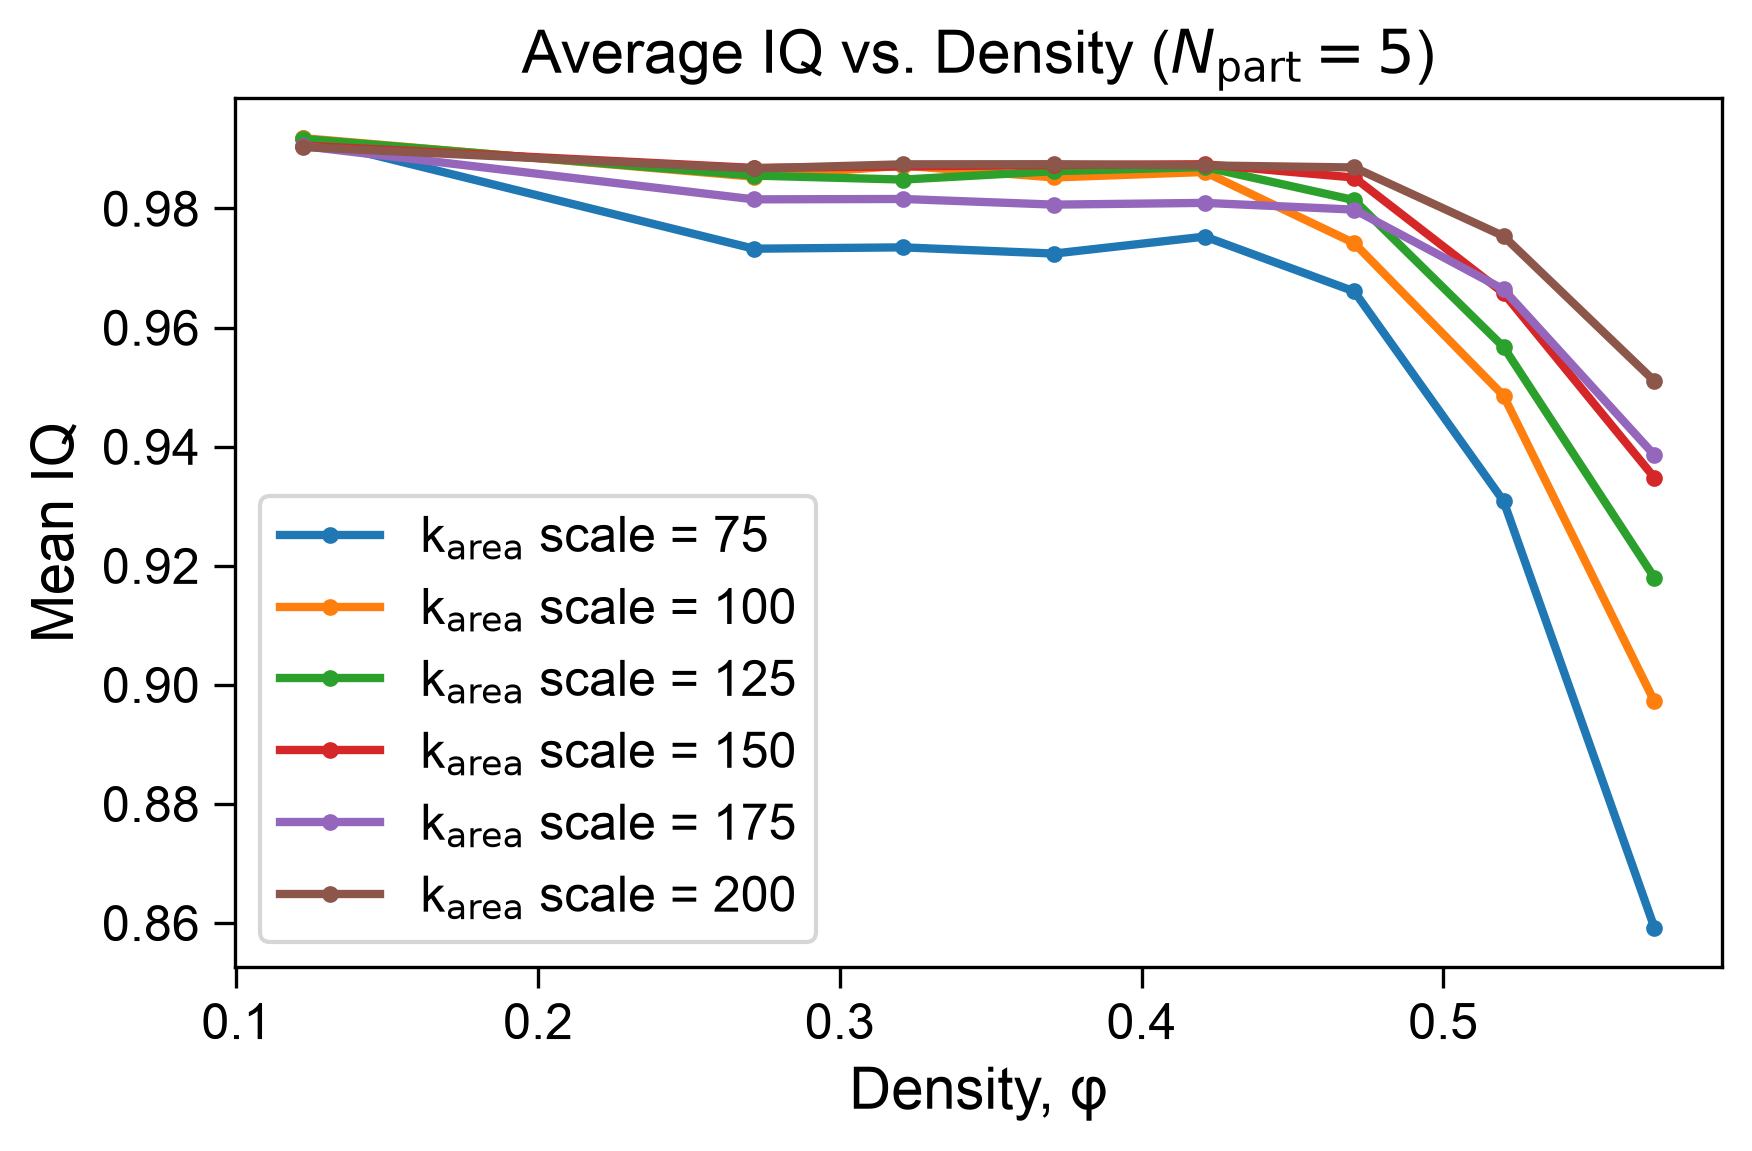

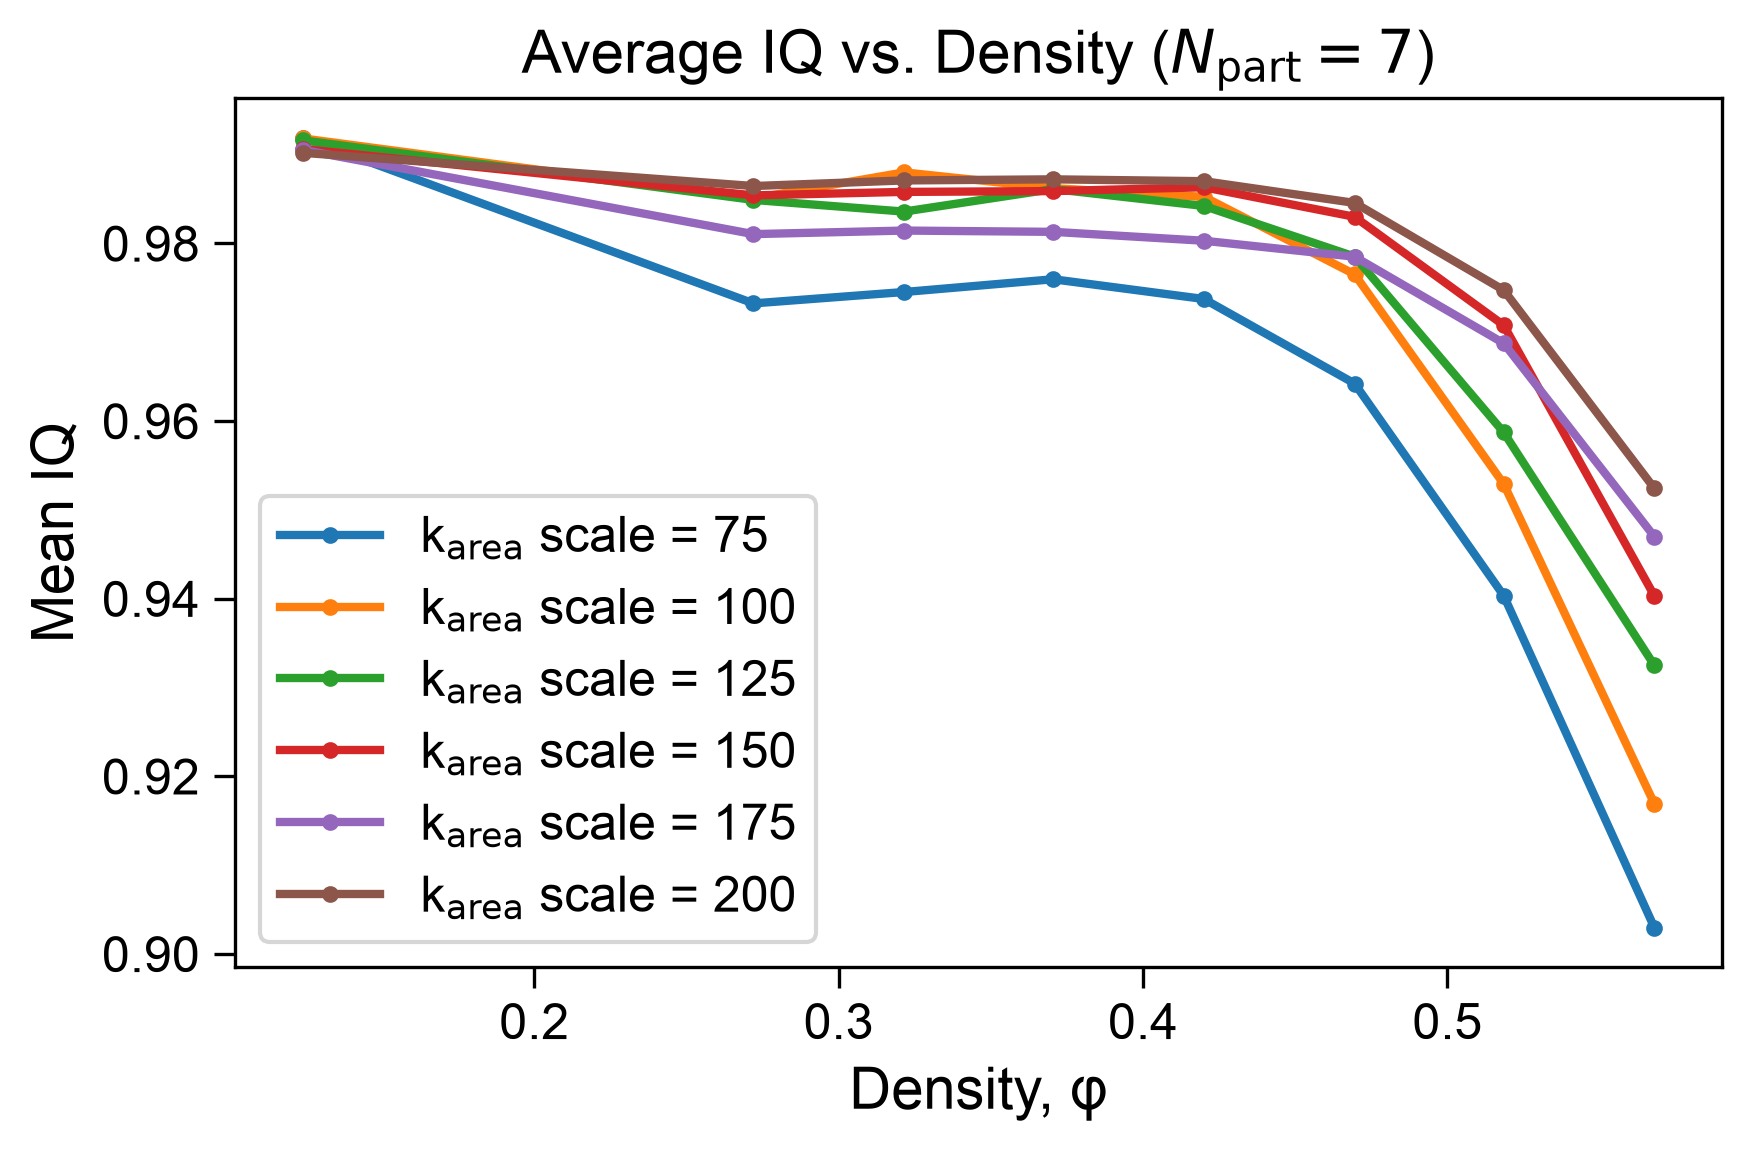

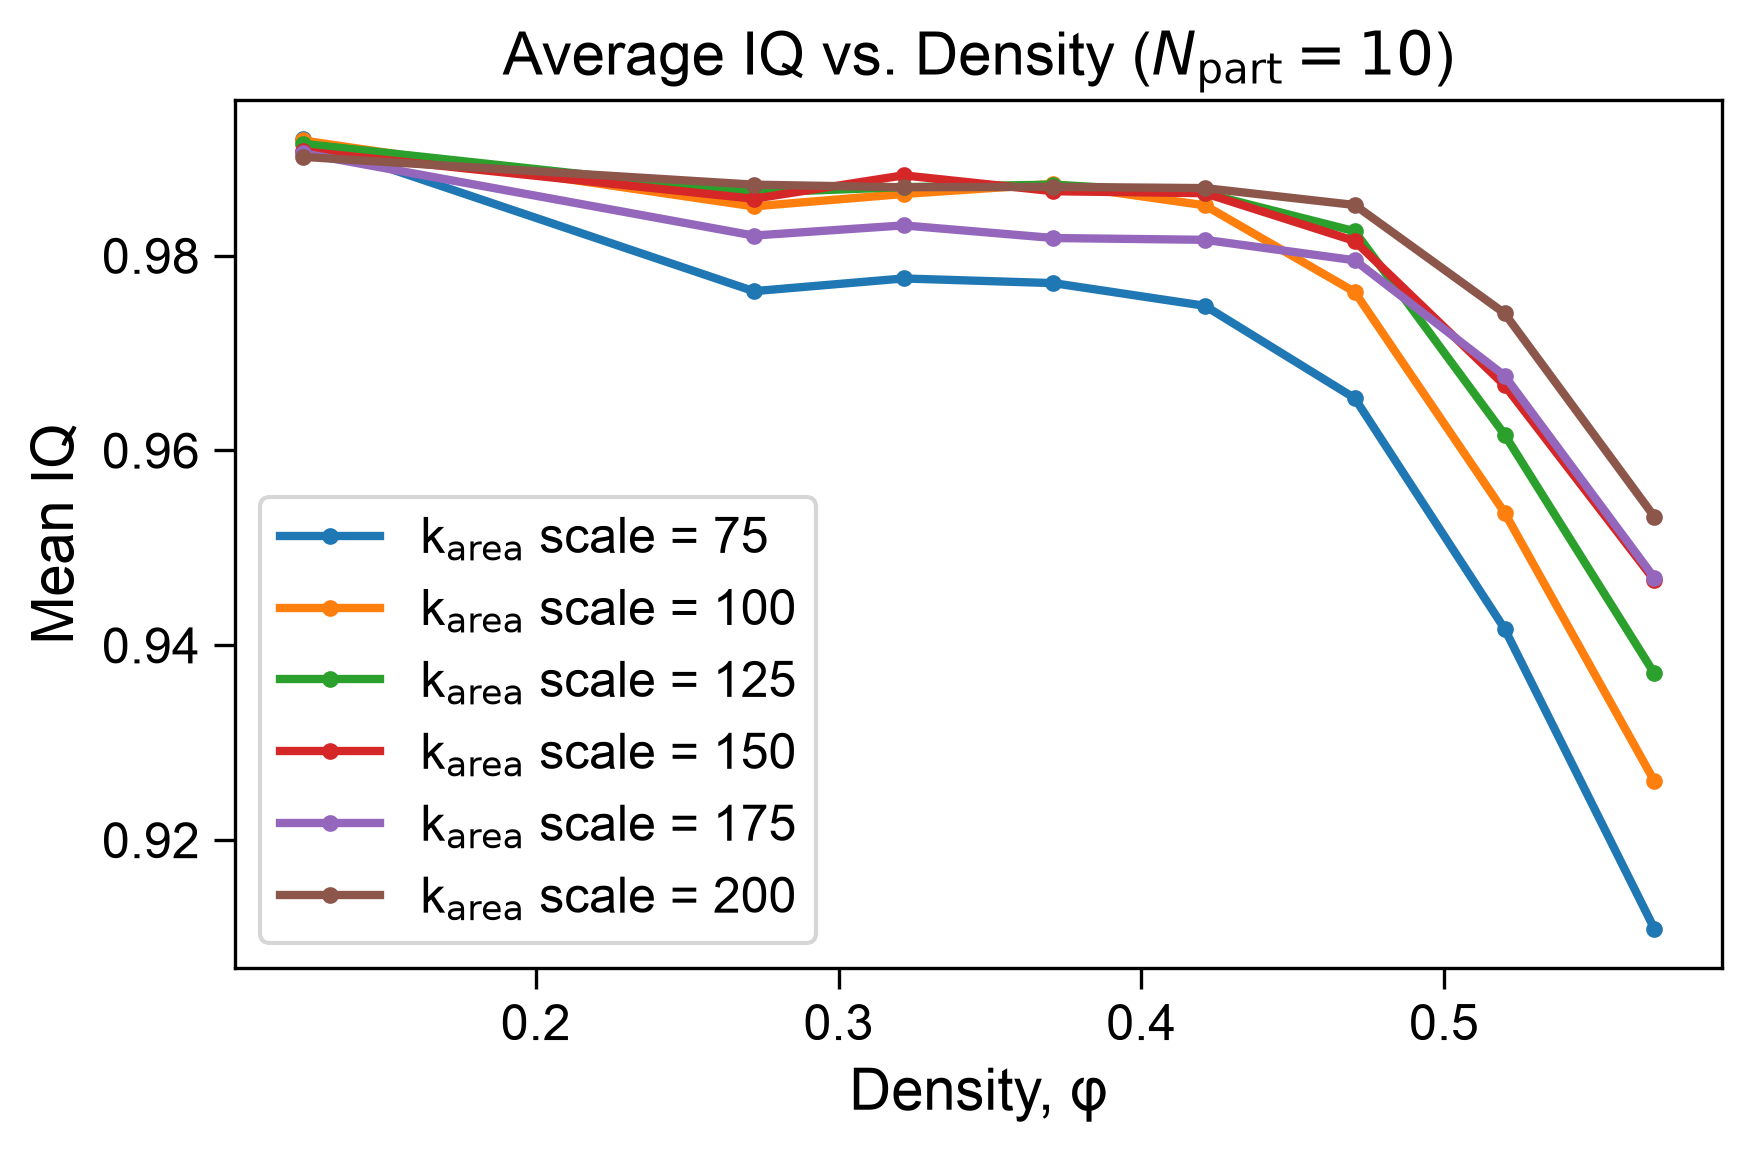

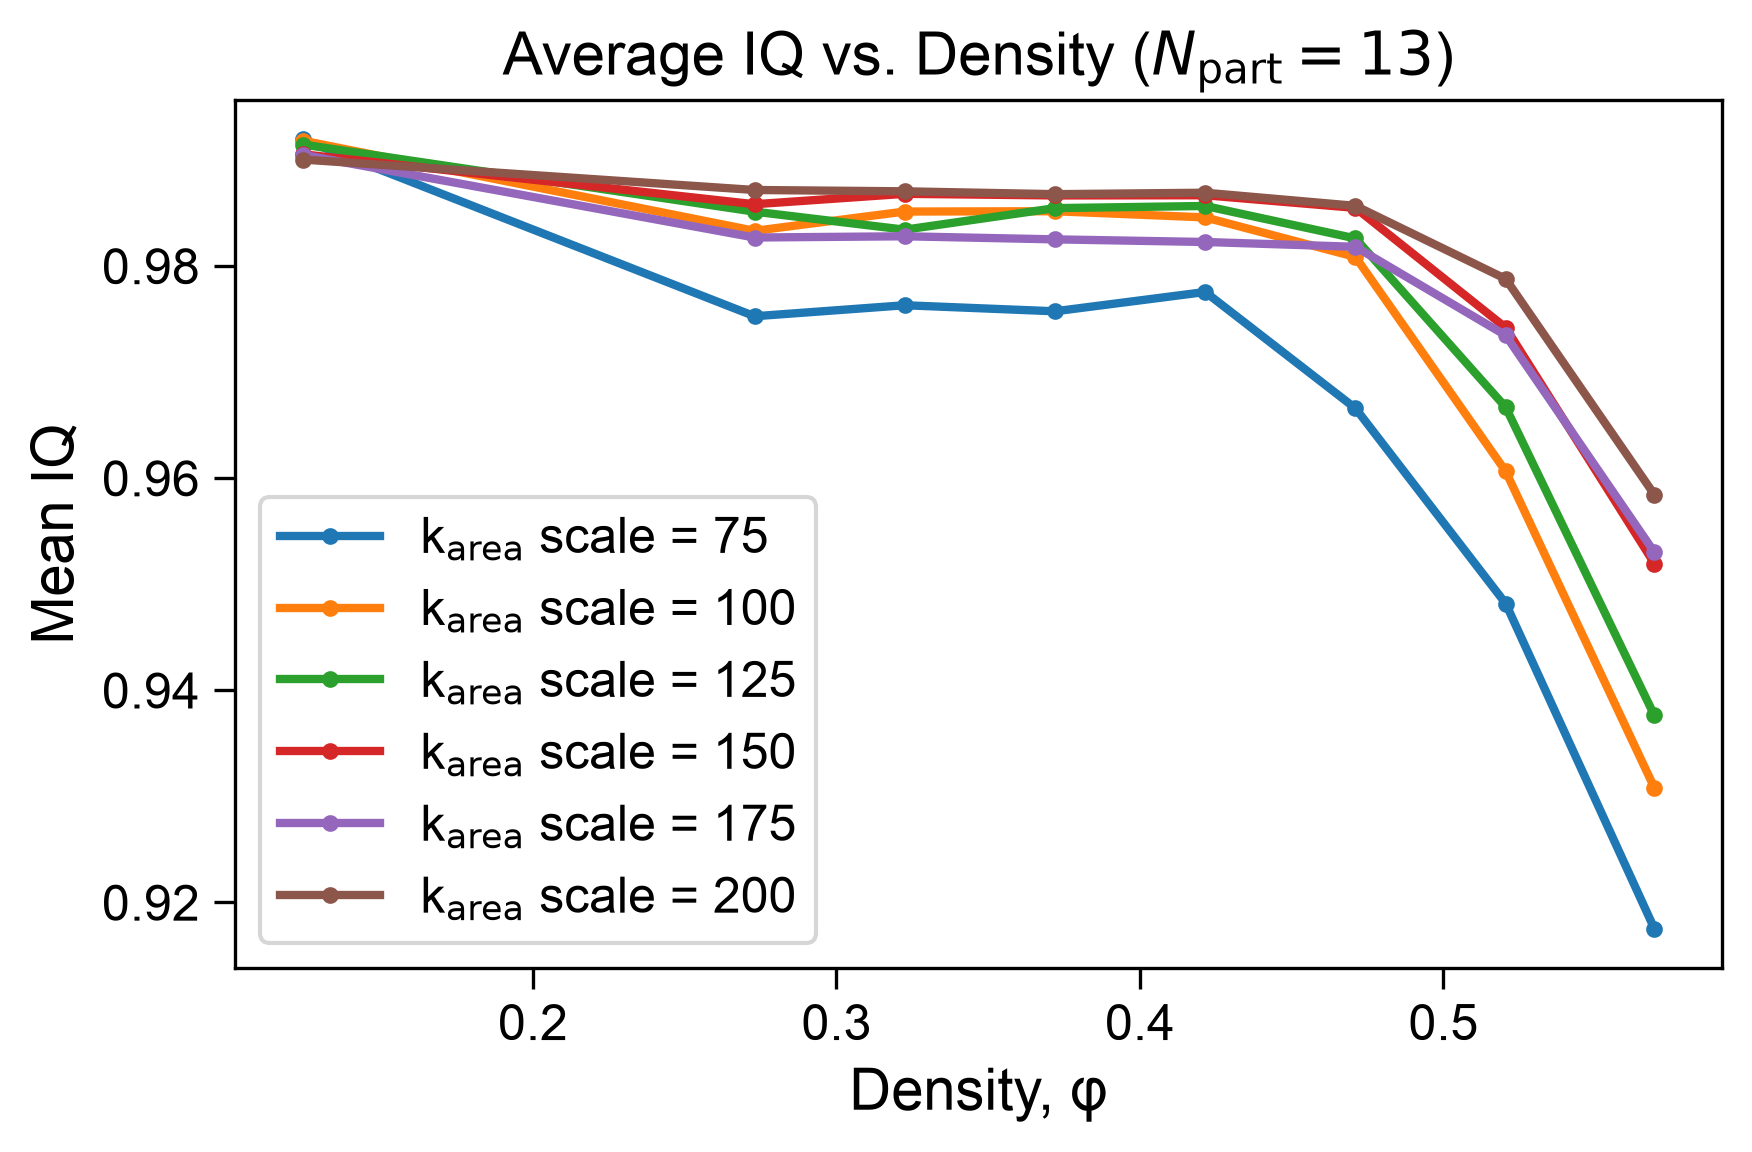

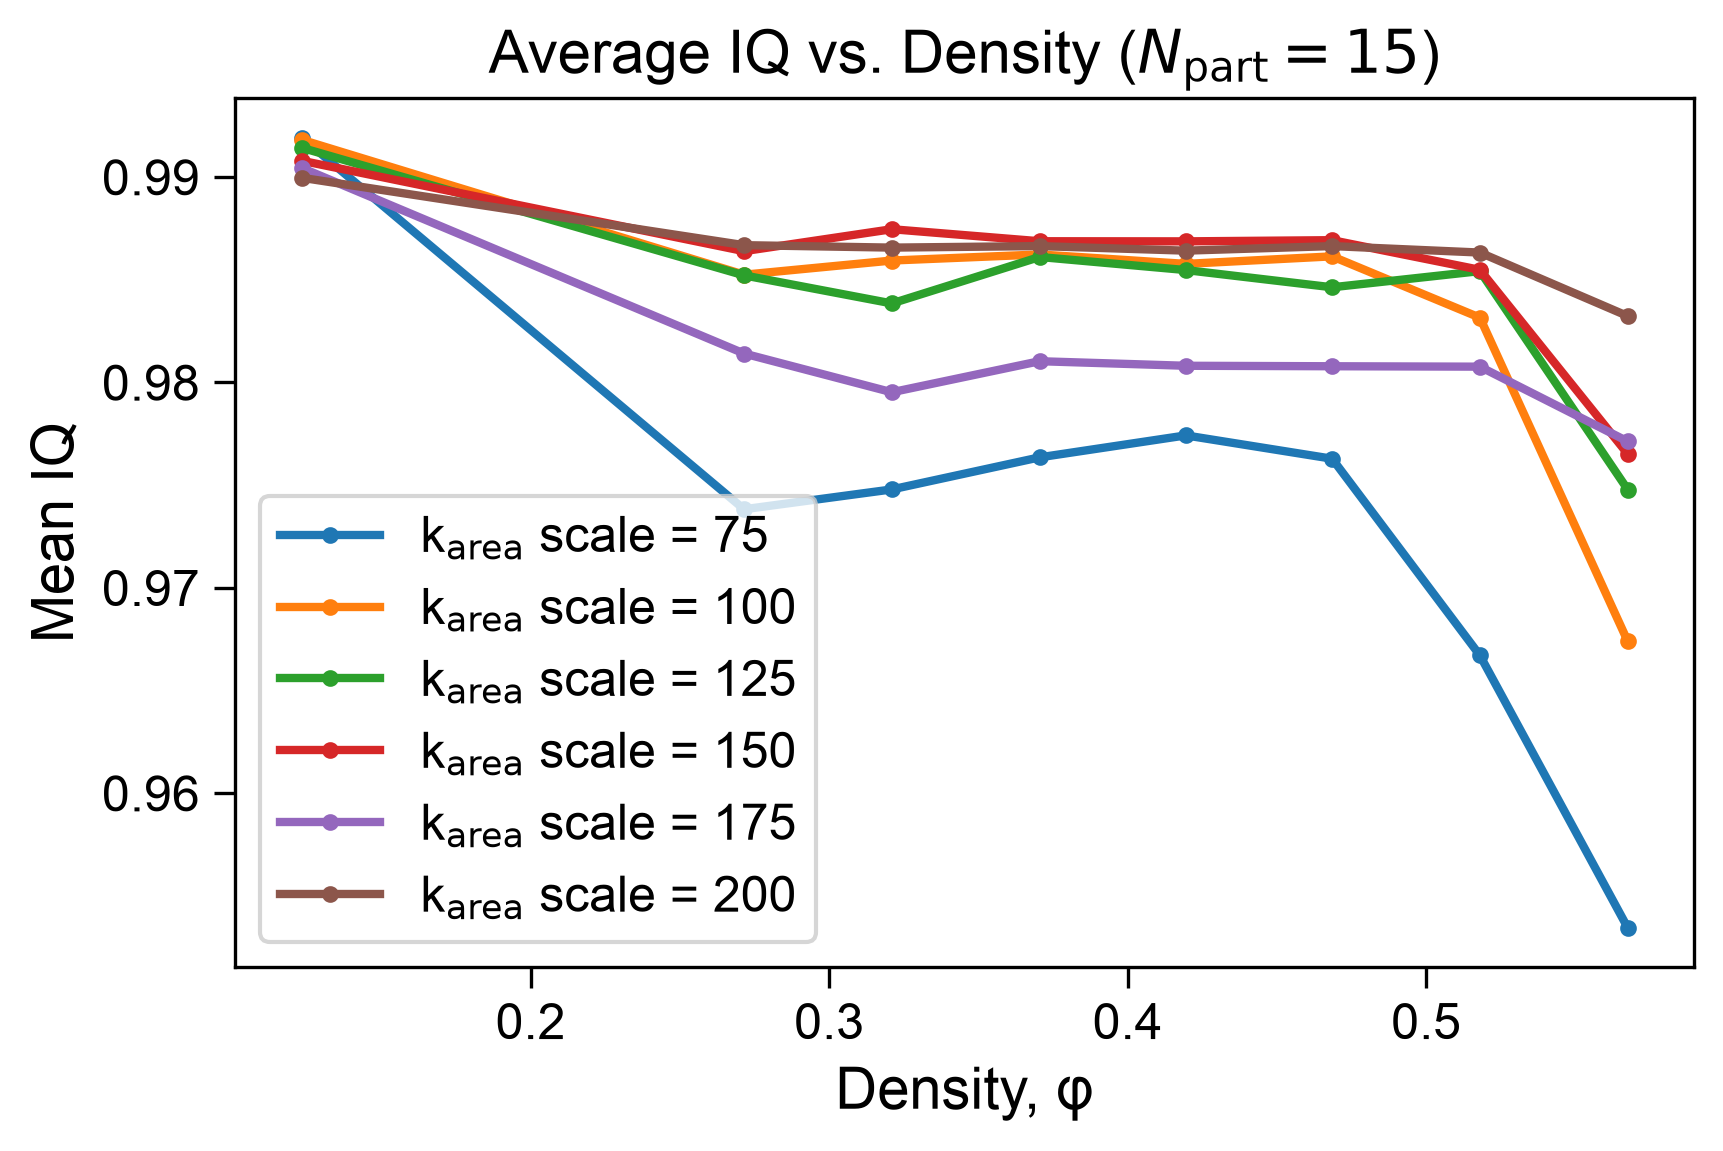

In [ ]:
for N_part in [5, 7, 10, 13, 15]: 
    plot_iq_vs_density(project, N_part, 4, 2.09, n_bins = 10)

In [ ]:
rows = []
for job in project.find_jobs():
    if job.isfile('trajectory.gsd') and job.sp.k_volume_scale == 100000 and job.sp.k_harm == 100 and job.sp.sigma == 2.09 and job.sp.k_harm == 100 and job.sp.k_area_scale != 50:
        traj = gsd.hoomd.open(job.fn("trajectory.gsd"))
        frame = traj[-1]
        box = freud.box.Box.from_box(frame.configuration.box)
        data = analyze_frame(frame, job.sp.N_part, job.sp.N_mesh, job.sp.sigma, box, job.sp.k_harm, alpha = 0.7)
        data["job_id"] =  job.id
        data["k_area_scale"] = job.sp.k_area_scale
        data["N_part"] = job.sp.N_part
        rows.append(data)

df = pd.DataFrame(rows)
for i, col in enumerate(["N_part", "job_id", "k_area_scale"]): 
    df.insert(i, col, df.pop(col))
        
df = df.sort_values(by = ["N_part", "k_area_scale", "job_id"]).reset_index(drop = True)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df

,N_part,job_id,k_area_scale,avg_IQ,total_area,avg_area,efficiency,degrees,avg_degree,num_edges,avg_particle_num,avg_pair_force,avg_particle_force,avg_net_force,min_net_force,max_net_force,std_net_force
0,5,0596e151d5baf9f7f408e3128a453aed,75,0.862,517.545,103.509,0.770,"[4, 4, 4, 4, 4]",4.000,10.0,110.400,566.629,5.082,0.764,0.405,1.508,0.403
1,5,1fef3d4374368e4baef90f909c0bf449,75,0.844,514.921,102.984,0.766,"[4, 4, 4, 4, 4]",4.000,10.0,113.000,544.553,4.973,1.404,0.423,2.025,0.583
2,5,b8e3824e29744db8966d8acaa24b917b,75,0.853,516.118,103.224,0.768,"[4, 4, 4, 4, 4]",4.000,10.0,114.600,555.948,4.933,0.381,0.100,0.715,0.268
3,5,f217ba822e4ccfbad82166e706b4ea22,75,0.834,511.858,102.372,0.762,"[4, 4, 4, 4, 4]",4.000,10.0,119.700,547.566,4.738,0.717,0.373,0.854,0.174
4,5,f3e86af17f33af30aa2ccbea3121cbf4,75,0.813,508.558,101.712,0.757,"[4, 4, 4, 4, 4]",4.000,10.0,121.100,533.000,4.775,0.689,0.069,1.121,0.393
5,5,5998c9b6111212824dea3f10bdcb8ee9,100,0.864,506.437,101.287,0.754,"[4, 4, 4, 4, 4]",4.000,10.0,92.100,437.965,4.843,1.130,0.637,2.026,0.507
6,5,9acfe8d1c608ab3d00d1477d54f7ca9f,100,0.865,506.638,101.328,0.754,"[4, 4, 3, 3, 4]",3.600,9.0,91.400,436.463,4.782,1.526,0.441,2.238,0.594
7,5,da723c0d4540fd7e26c6f014ccfac91c,100,0.873,507.961,101.592,0.756,"[4, 4, 4, 4, 4]",4.000,10.0,90.400,431.429,4.764,0.940,0.281,1.526,0.458
8,5,dec6aaf54e6760226c046ed820ec5549,100,0.888,509.184,101.837,0.758,"[4, 4, 4, 4, 4]",4.000,10.0,91.200,450.639,4.906,1.411,0.346,1.825,0.547
9,5,fe6fd309e8e89dc961687ed5c7312f30,100,0.863,506.001,101.200,0.753,"[4, 4, 4, 4, 4]",4.000,10.0,90.200,420.815,4.670,0.831,0.375,1.188,0.262


In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["avg_IQ"].mean()
    std = subset.groupby("k_area_scale")["avg_IQ"].std()
    # plt.plot(avg.index, avg.values, marker = ".")
    plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = rf"$N_{{\mathrm{{part}}}} = {N}$")
plt.xlabel(r"k$_{\mathrm{area}}$ scale") 
plt.ylabel("Mean IQ") 
plt.legend()
plt.tight_layout()
plt.title(r"Mean IQ per Mesh vs. k$_{\mathrm{area}}$ scale" )
plt.xticks([75, 100, 125, 150, 175, 200])
# plt.savefig('IQ vs k.png', bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["efficiency"].mean()
    std = subset.groupby("k_area_scale")["efficiency"].std()
    plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = rf"$N_{{\mathrm{{part}}}} = {N}$")
plt.xlabel(r"k$_{\mathrm{area}}$ scale") 
plt.ylabel("Packing Efficiency") 
plt.legend()
plt.tight_layout()
plt.xticks([75, 100, 125, 150, 175, 200])
plt.title(r"Packing Efficiency vs. k$_{\mathrm{area}}$ scale")
# plt.savefig('Packing vs k.png', bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["avg_degree"].mean()
    std = subset.groupby("k_area_scale")["avg_degree"].std()
    plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = rf"$N_{{\mathrm{{part}}}} = {N}$")
plt.xlabel(r"k$_{\mathrm{area}}$ scale") 
plt.ylabel("Mean Contact Degree") 
plt.legend()
plt.tight_layout()
plt.xticks([75, 100, 125, 150, 175, 200])
plt.title(r"Contact Degree per Mesh vs k$_{{\mathrm{area}}}$ scale")
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["num_edges"].mean()
    std = subset.groupby("k_area_scale")["num_edges"].std()
    plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = rf"$N_{{\mathrm{{part}}}} = {N}$")
plt.xlabel(r"k$_{\mathrm{area}}$ scale")
plt.ylabel("Mean Number of Contacts") 
plt.legend()
plt.tight_layout()
plt.xticks([75, 100, 125, 150, 175, 200])
plt.title(r"Number of Contacts Between All Meshes vs k$_{{\mathrm{area}}}$ scale")
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["avg_particle_num"].mean()
    std = subset.groupby("k_area_scale")["avg_particle_num"].std()
    plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = rf"$N_{{\mathrm{{part}}}} = {N}$")
plt.xlabel(r"k$_{\mathrm{area}}$ scale") 
plt.ylabel("Number of Interacting Particles") 
plt.legend()
plt.tight_layout()
plt.xticks([75, 100, 125, 150, 175, 200])
plt.title(r"Number of Interacting Particles vs. k$_{\mathrm{area}}$ scale")
# plt.savefig('Contact particle vs k.png', bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["avg_pair_force"].mean()
    std = subset.groupby("k_area_scale")["avg_pair_force"].std()
    plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = rf"$N_{{\mathrm{{part}}}} = {N}$")
plt.xlabel(r"k$_{\mathrm{area}}$ scale") 
plt.ylabel("Mean Pair Mesh Force") 
plt.legend()
plt.tight_layout()
plt.xticks([75, 100, 125, 150, 175, 200])
plt.title(r"Force Between Each Mesh Pair vs. k$_{\mathrm{area}}$ scale")
# plt.savefig('Pair force vs k.png', bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["avg_particle_force"].mean()
    std = subset.groupby("k_area_scale")["avg_particle_force"].std()
    plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = rf"$N_{{\mathrm{{part}}}} = {N}$")
plt.xlabel(r"k$_{\mathrm{area}}$ scale") 
plt.ylabel("Mean Force per Particle") 
plt.legend()
plt.tight_layout()
plt.xticks([75, 100, 125, 150, 175, 200])

plt.show()

In [ ]:
plt.figure(figsize=(6,4))
for N in [5, 7, 10, 13, 15]: 
    subset = df[df["N_part"] == N]
    avg = subset.groupby("k_area_scale")["avg_net_force"].mean()
    std = subset.groupby("k_area_scale")["avg_net_force"].std()
    plt.plot(avg.index, avg.values,marker = ".",  label = rf"$N_{{\mathrm{{part}}}} = {N}$")
    # plt.errorbar(avg.index, avg.values, yerr = std.values, marker = ".", capsize = 4, label = f"{N} meshes")
plt.xlabel(r"k$_{\mathrm{area}}$ scale") 
plt.ylabel("Mean Net Force per Mesh") 
plt.legend()
plt.tight_layout()
plt.xticks([75, 100, 125, 150, 175, 200])

plt.show()

In [ ]:
def get_max_intermesh_force(project, N_part):
    max_force = 0
    for job in project.find_jobs({"N_part": N_part}):
        if (job.isfile("trajectory.gsd") and job.sp.k_volume_scale == 100000 and job.sp.k_harm == 100 and job.sp.k_bend == 1.0 and job.sp.sigma == 2.09):
            traj = gsd.hoomd.open(job.fn("trajectory.gsd"))
            frame = traj[-1]
            box = freud.box.Box.from_box(frame.configuration.box)
            force = forces_between_mesh(frame,job.sp.N_part,job.sp.N_mesh,job.sp.sigma,job.sp.k_harm,box,)
            current_max = max(force["pair_force"].values())

            if current_max > max_force:
                max_force = current_max

    return math.ceil(max_force / 100) * 100
    
    
def intermesh_force_heatmap(project, N_part, max_force): 
    for job in project.find_jobs({"N_part": N_part}):
        if job.isfile('trajectory.gsd') and job.sp.k_area_scale != 50 and job.sp.k_volume_scale == 100000 and job.sp.k_harm == 100 and job.sp.sigma == 2.09 and job.sp.k_harm == 100 and job.sp.k_bend == 1.0:
            if getattr(job.sp, "replica_index", None) == 0: 
                # print(job.id)
                traj = gsd.hoomd.open(job.fn("trajectory.gsd"))
                frame = traj[-1]
                box = freud.box.Box.from_box(frame.configuration.box)
                force = forces_between_mesh(frame, job.sp.N_part, job.sp.N_mesh, job.sp.sigma, job.sp.k_harm, box)
                matrix = np.zeros((job.sp.N_part,job.sp.N_part))
                for (i, j), value in force["pair_force"].items():
                    matrix[i,j] = value
                    matrix[j,i] = value
                plt.figure(figsize = (6,5))
                plt.imshow(matrix, vmin = 0, vmax = max_force)
                # plt.colorbar(label = "Total inter-mesh force")
                plt.xticks(range(job.sp.N_part))
                plt.yticks(range(job.sp.N_part))
                plt.xlabel("Mesh")
                plt.ylabel("Mesh") 
                plt.title(rf"Pair Mesh Force Heatmap ($N_{{\mathrm{{part}}}} = {job.sp.N_part}$, $k_{{\mathrm{{area}}}}$ scale={job.sp.k_area_scale})")    
                # plt.savefig(f"{job.sp.k_area_scale}.png", bbox_inches='tight')
                # for i in range(job.sp.N_part):
                #     for j in range(job.sp.N_part):
                #         if matrix[i, j] > 0: 
                #             plt.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center", color="black" if matrix[i,j] > matrix.max()/2 else "white", fontsize=8)
                plt.show

In [ ]:
for N_part in [7, 13]: 
    intermesh_force_heatmap(project, N_part, get_max_intermesh_force(project, N_part))

In [ ]:
# plotting the harmonic potential graph
k = 100
sigma = 2.09

x_margin = 0.15 
x = np.linspace(-x_margin, sigma + x_margin, 500)
y = harmonic_U(k, sigma, x)

fig, ax = plt.subplots()

ax.plot(x, y,label=r"$U(r)=\frac{k_{\mathrm{harm}}}{2}\left(1-\frac{r}{\sigma}\right)^2$")
ax.plot(sigma, 0, "o", color="green", zorder=5)             
ax.plot(0, U(0), "o", color="green", zorder=5)            
ax.annotate(rf"$(\sigma, 0)$", xy=(sigma, 0), xytext=(sigma - 0.05, 6), fontsize = 16, ha="right")
ax.annotate(rf"$(0, \frac{{k_{{\mathrm{{harm}}}}}}{{2}})$", xy=(0, U(0)), xytext=(0.05, U(0) + 3), fontsize = 16)
ax.set_xlim(-x_margin, sigma + x_margin)
ax.set_ylim(-10, 80)

ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

for spine in ax.spines.values(): 
    spine.set_visible(False)

ax.set_xlabel("r")
ax.set_ylabel("U(r)")
ax.set_title("Harmonic Force Equation")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=20)

plt.tight_layout()
# plt.savefig("plot.png", bbox_inches='tight')
plt.show()